#Part 1 — Data Understanding & Exploration

#Perform basic data exploration and preprocessing.

#Tasks:

#1.Load the dataset using Pandas

#2.Explore dataset structure:

#a.Shape of dataset

#b.Column types

#c.Missing values

#3.Perform basic statistical analysis

#4.Visualize relationships between features and diabetes. /*

In [58]:
#1.Load the dataset using Pandas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
data=pd.read_csv("/content/healthcare_dataset.csv")
data.head()

,patient_id,age,bmi,exercise_hours_per_week,smoker,blood_pressure,diabetes
0,1,31,18.3,1.5,0,119.1,0
1,2,44,26.3,3.1,0,120.5,0
2,3,43,24.2,4.8,0,130.3,0
3,4,32,25.0,6.0,0,119.5,0
4,5,28,22.1,4.2,1,127.4,0


In [59]:
#2.Explore dataset structure:

#a.Shape of dataset
data.shape
#to know the rows and columns

#b.Column types
data.dtypes
#to know columns and data types
data.info()
#to know column,datatype,nonull count

#c.Missing values
data.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   patient_id               6000 non-null   int64  
 1   age                      6000 non-null   int64  
 2   bmi                      6000 non-null   float64
 3   exercise_hours_per_week  6000 non-null   float64
 4   smoker                   6000 non-null   int64  
 5   blood_pressure           6000 non-null   float64
 6   diabetes                 6000 non-null   int64  
dtypes: float64(3), int64(4)
memory usage: 328.3 KB


,0
patient_id,0
age,0
bmi,0
exercise_hours_per_week,0
smoker,0
blood_pressure,0
diabetes,0


In [60]:
#3.Perform basic statistical analysis
data.describe()
#gives all statistical values

data['diabetes'].value_counts()
#how many people have diabetics



,count
diabetes,
0,5458
1,542


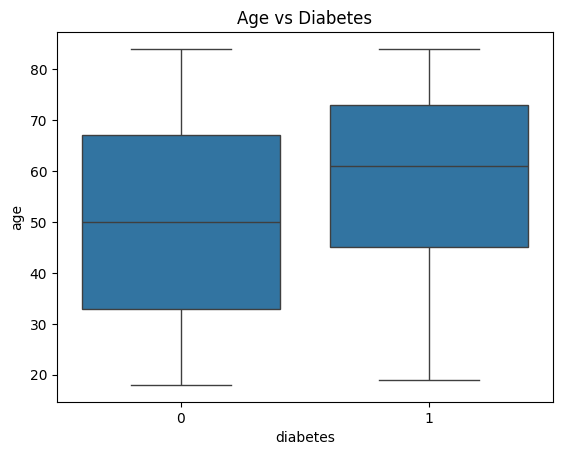

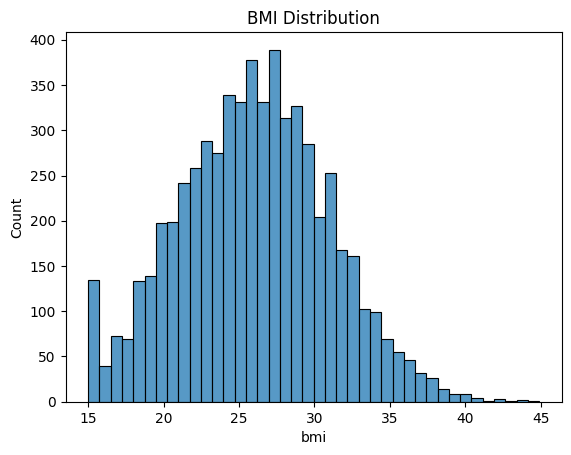

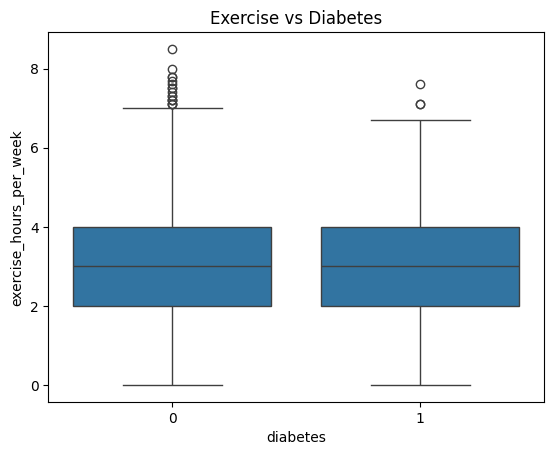

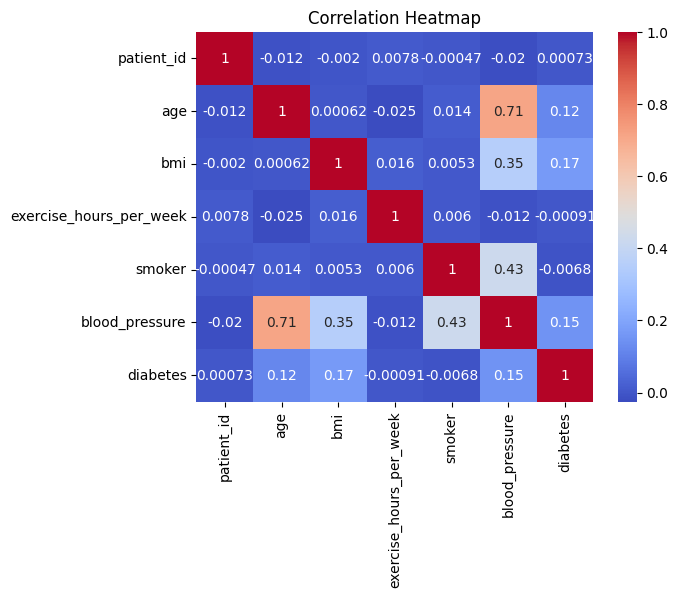

In [61]:
#Visualisations
# Age vs Diabetes
sns.boxplot(x='diabetes', y='age', data=data)
plt.title("Age vs Diabetes")
plt.show()

# BMI distribution
sns.histplot(data['bmi'])
plt.title("BMI Distribution")
plt.show()

# Exercise vs Diabetes
sns.boxplot(x='diabetes', y='exercise_hours_per_week', data=data)
plt.title("Exercise vs Diabetes")
plt.show()

# Correlation Heatmap
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

#Part 2 — Machine Learning Classification Model

#Build a Machine Learning model to predict diabetes.

#Tasks:

#1.Separate features (X) and target variable (y)

#2.Perform train-test split

#3.Apply feature scaling

#4.Train a Logistic Regression classifier

#5.Generate predictions

#6.Evaluate model performance

In [62]:

#1.Separate features (X) and target variable (y)

#data used to predict
x = data.drop(['diabetes', 'patient_id'], axis=1)
# Target (what we want to predict)
y = data['diabetes']
x.head()
y.head()


,diabetes
0,0
1,0
2,0
3,0
4,0


In [63]:
#2.Perform train-test split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)
#testing will be 20% data,training will be 80%data

In [64]:
#3.Apply feature scaling
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
# Fit on training data, transform both
X_train = scaler.fit_transform(x_train)
X_test = scaler.transform(x_test)
#different features may have differnt range of values,so model may get confused
#Scaling makes all features:Mean = 0 && Std = 1

In [65]:
#4.Train a Logistic Regression classifier
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)
#Model learns:Relationship between inputs and diabetes.It finds a decision boundary:Who is diabetic vs not

LogisticRegression()

In [66]:
#5.Generate predictions
y_pred = model.predict(X_test)
#For each test patient:Predicts 0 or 1

In [67]:
#6.Evaluate model performance
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Full Report
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9166666666666666
Confusion Matrix:
 [[1100    0]
 [ 100    0]]
Classification Report:
               precision    recall  f1-score   support

           0       0.92      1.00      0.96      1100
           1       0.00      0.00      0.00       100

    accuracy                           0.92      1200
   macro avg       0.46      0.50      0.48      1200
weighted avg       0.84      0.92      0.88      1200



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Part 3 — Neural Network Model

Build a basic Artificial Neural Network using TensorFlow/Keras.

Tasks:

1.Create a Sequential neural network model

2.Add:

a.Input layer

b.Hidden layers

c.Output layer

3.Compile model using:

a.Adam optimizer

b.Binary crossentropy loss

4.Train the model

5.Evaluate performance on test data

In [68]:
#1.Create a Sequential neural network model
# Import required libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model_nn = Sequential()

In [69]:
#2.Add layers

# Input layer
model_nn.add(Dense(16, activation='relu', input_shape=(X_train.shape[1],)))

# Hidden layer
model_nn.add(Dense(8, activation='relu'))

# Output layer
model_nn.add(Dense(1, activation='sigmoid'))

# Input layer: takes features
# Hidden layers: learn patterns
# ReLU: handles non-linearity
# Sigmoid: outputs probability (0 to 1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [70]:
#3.Compile model using: a.Adam optimizer && b.Binary crossentropy loss

model_nn.compile(
    optimizer='adam',              # efficient optimizer
    loss='binary_crossentropy',    # for binary classification
    metrics=['accuracy']
)

In [79]:
#4.Train the model

history = model_nn.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

# epochs = number of times model sees data
# batch_size = number of samples per step

Epoch 1/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9107 - loss: 0.2732 - val_accuracy: 0.8969 - val_loss: 0.3192
Epoch 2/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9107 - loss: 0.2728 - val_accuracy: 0.8969 - val_loss: 0.3177
Epoch 3/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9107 - loss: 0.2725 - val_accuracy: 0.8969 - val_loss: 0.3181
Epoch 4/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9107 - loss: 0.2723 - val_accuracy: 0.8969 - val_loss: 0.3193
Epoch 5/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9107 - loss: 0.2723 - val_accuracy: 0.8969 - val_loss: 0.3181
Epoch 6/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9107 - loss: 0.2720 - val_accuracy: 0.8969 - val_loss: 0.3183
Epoch 7/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9107 - loss: 0.2718 - val_accuracy: 0.8969 - val_loss: 0.3199
Epoch 8/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9107 - loss: 0.2717 - val_accuracy:

In [72]:
#5.Evaluate performance on test data

loss, accuracy = model_nn.evaluate(X_test, y_test)

print("Neural Network Accuracy:", accuracy)

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9167 - loss: 0.2753
Neural Network Accuracy: 0.9166666865348816


In [73]:
# Generate predictions

y_pred_nn = model_nn.predict(X_test)

# Convert probabilities to 0 or 1
y_pred_nn = (y_pred_nn > 0.5).astype(int)
from sklearn.metrics import confusion_matrix, classification_report

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_nn))
print("Classification Report:\n", classification_report(y_test, y_pred_nn))

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Confusion Matrix:
 [[1100    0]
 [ 100    0]]
Classification Report:
               precision    recall  f1-score   support

           0       0.92      1.00      0.96      1100
           1       0.00      0.00      0.00       100

    accuracy                           0.92      1200
   macro avg       0.46      0.50      0.48      1200
weighted avg       0.84      0.92      0.88      1200



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


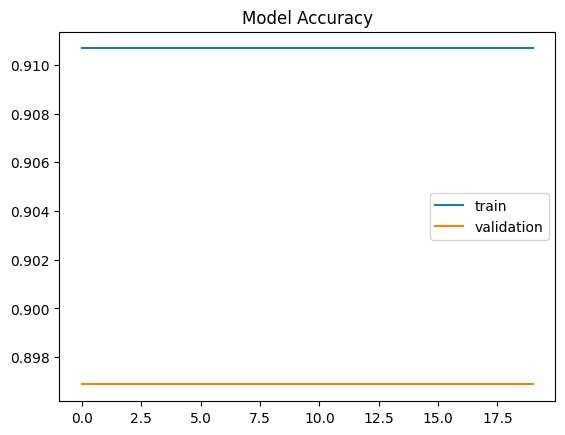

In [80]:
#Training performance visualization
import matplotlib.pyplot as plt

# Accuracy graph
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='validation')
plt.legend()
plt.title("Model Accuracy")
plt.show()